<a href="https://colab.research.google.com/github/FarahBelghith2/PFE/blob/main/Pr%C3%A9paration_des_donn%C3%A9es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Préparation des données
## CRISP-DM – Phase Data Preparation

Ce notebook est dédié à l’enrichissement de la base de données
par des sources externes (APIs officielles).

APIs utilisées :
- Jours fériés (Etalab)
- Vacances scolaires (data.education.gouv.fr)
- Événements publics (OpenAgenda)
- Météo historique (Open-Meteo)

Objectif :
Produire une base enrichie, cohérente et prête pour la modélisation.

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from google.colab import drive
drive.mount('/content/drive')

sns.set_style("whitegrid")

Mounted at /content/drive


## Configuration globale

Définition :
- de la période cible,
- des zones géographiques,
- des paramètres nécessaires aux APIs.

In [2]:
INPUT_PATH_A = "/content/drive/MyDrive/PFE/base_propre_corrigee.csv"

TARGET_START = "2024-01-01"
TARGET_END = "2025-12-31"   # pour la préparation de la base

annee_actuelle = datetime.now().year
API_EVENT_END = f"{annee_actuelle}-12-31"   # pour l'API des événements seulement

ZONE_FERIES = "metropole"
ZONE_SCOLAIRE = "C"
DEPARTEMENT = "Paris"
VILLE = None

BIG_EVENT_KEYWORDS = [
    "concert", "festival", "spectacle", "show",
    "champion", "champions league", "ligue des champions",
    "coupe", "cup", "finale", "tournoi", "match",
    "euro", "world cup", "coupe du monde",
    "olympique", "jo", "jeu olympique", "jeux olympiques"
]

mapping_type_admin = {
    "none": "Aucun événement",
    "concert": "Concert / festival",
    "sport": "Événement sportif",
    "champions_league": "Grand match",
    "other": "Événement local"
}

mapping_impact_admin = {
    0: "Aucun",
    1: "Faible",
    2: "Moyen",
    3: "Fort"
}



## Fonctions de base : nettoyage et calendrier

In [3]:
def month_to_season_fr(month):
    if month in [12, 1, 2]:
        return "hiver"
    elif month in [3, 4, 5]:
        return "printemps"
    elif month in [6, 7, 8]:
        return "été"
    else:
        return "automne"

def nettoyer_colonnes_baseA(df):
    cols_to_drop = [
        "date_originale", "nom_vacances", "type_event_local",
        "capacite_max", "meteo_avant_patch", "taux_occupation",
        "reservations_avant", "is_special_event", "nom_evenement"
    ]
    return df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")

def remapper_dates_vers_2024_2025(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["date"]).copy()

    unique_dates = sorted(df["date"].dt.normalize().unique())
    target_dates = pd.date_range(start=TARGET_START, end=TARGET_END, freq="D")

    if len(unique_dates) != len(target_dates):
        raise ValueError(
            f"La base contient {len(unique_dates)} jours uniques, "
            f"mais la plage {TARGET_START} -> {TARGET_END} en contient {len(target_dates)}."
        )

    mapping = {pd.Timestamp(src): pd.Timestamp(dst) for src, dst in zip(unique_dates, target_dates)}
    df["date"] = df["date"].dt.normalize().map(mapping)

    return df

def recalculer_calendrier(df):
    df = df.copy()

    map_jour_fr = {
        0: "lundi",
        1: "mardi",
        2: "mercredi",
        3: "jeudi",
        4: "vendredi",
        5: "samedi",
        6: "dimanche"
    }

    df["annee"] = df["date"].dt.year
    df["mois"] = df["date"].dt.month
    df["jour_mois"] = df["date"].dt.day
    df["jour_semaine_num"] = df["date"].dt.weekday
    df["jour_semaine"] = df["jour_semaine_num"].map(map_jour_fr)
    df["est_weekend"] = (df["jour_semaine_num"] >= 5).astype(int)
    df["semaine_annee"] = df["date"].dt.isocalendar().week.astype(int)
    df["trimestre"] = df["date"].dt.quarter
    df["saison_auto"] = df["mois"].apply(month_to_season_fr)
    df["saison"] = df["saison_auto"]

    return df

## API Jours Fériés (France)

Cette API permet d’identifier les jours fériés officiels
et de déterminer si un jour est ouvrable ou non.

In [4]:
def charger_jours_feries_france(zone="metropole"):
    url = f"https://etalab.github.io/jours-feries-france-data/json/{zone}.json"

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    data = response.json()

    feries = pd.DataFrame(list(data.items()), columns=["date_ferie", "nom_jour_ferie"])
    feries["date_ferie"] = pd.to_datetime(feries["date_ferie"], errors="coerce").dt.normalize()
    feries["ferie"] = 1
    return feries

def ajouter_jours_feries_baseA(df):
    df = df.copy()
    df = df.drop(columns=[c for c in ["ferie", "nom_jour_ferie"] if c in df.columns], errors="ignore")

    # Sécurité : si jour_semaine_num n'existe pas, on le recalcule
    if "jour_semaine_num" not in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["jour_semaine_num"] = df["date"].dt.weekday

    feries = charger_jours_feries_france(ZONE_FERIES)
    df["date_norm"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()

    df = df.merge(
        feries[["date_ferie", "ferie", "nom_jour_ferie"]],
        how="left",
        left_on="date_norm",
        right_on="date_ferie"
    )

    # très important
    df["ferie"] = df["ferie"].fillna(0).astype(int)
    df["nom_jour_ferie"] = df["nom_jour_ferie"].fillna("Aucun")

    # jour ouvrable = lundi à vendredi ET non férié
    df["jour_ouvrable"] = ((df["jour_semaine_num"] < 5) & (df["ferie"] == 0)).astype(int)

    df.drop(columns=["date_norm", "date_ferie"], inplace=True, errors="ignore")
    return df


## API Vacances scolaires

Cette API permet de détecter les périodes de vacances scolaires
pour la zone sélectionnée.


In [5]:
def charger_vacances_scolaires_officielles(zone="C"):
    # URL de l'API officielle du gouvernement (Dataset des vacances scolaires)
    base_url = "https://data.education.gouv.fr/api/explore/v2.1/catalog/datasets/fr-en-calendrier-scolaire/records"

    all_rows = []
    offset = 0
    limit = 100

    # On récupère toutes les données (sans filtre complexe côté API pour éviter les bugs)
    while True:
        params = {
            "limit": limit,
            "offset": offset,
            "select": "description,start_date,end_date,zones,population"
        }

        try:
            resp = requests.get(base_url, params=params, timeout=30)
            resp.raise_for_status()
            data = resp.json()
        except requests.exceptions.RequestException as e:
            print(f"⚠️ Erreur de connexion à l'API Vacances Scolaires : {e}")
            break

        results = data.get("results", [])
        if not results:
            break

        all_rows.extend(results)

        # Gestion de la pagination (selon la version de l'API Opendatasoft)
        total_count = data.get("total_count", len(all_rows))
        offset += limit
        if offset >= total_count:
            break

    # Si l'API ne répond rien, on retourne un DataFrame vide avec les bonnes colonnes
    if not all_rows:
        print("⚠️ L'API Vacances n'a renvoyé aucune donnée.")
        return pd.DataFrame(columns=["description", "start_date", "end_date"])

    vac = pd.DataFrame(all_rows)

    # 1. Nettoyage basique
    for c in ["description", "start_date", "end_date", "zones", "population"]:
        if c not in vac.columns:
            vac[c] = None

    # Garder uniquement les "Élèves" (ignorer les vacances des professeurs si précisé)
    vac["population"] = vac["population"].astype(str).str.lower().str.strip()
    vac = vac[~vac["population"].str.contains("enseignant", na=False)].copy()

    # 2. Conversion propre des dates (UTC vers Naive)
    vac["start_date"] = pd.to_datetime(vac["start_date"], errors="coerce", utc=True).dt.tz_convert(None).dt.normalize()
    vac["end_date"] = pd.to_datetime(vac["end_date"], errors="coerce", utc=True).dt.tz_convert(None).dt.normalize()
    vac = vac.dropna(subset=["start_date", "end_date"]).copy()

    # 3. Filtrage intelligent de la Zone (C'est ICI que ça bloquait avant !)
    vac["zones"] = vac["zones"].astype(str).str.lower().str.strip()
    vac["description"] = vac["description"].astype(str).str.lower().str.strip()

    zone_label = f"zone {str(zone).lower()}"

    # Un jour de vacances est valide si :
    # - Il est explicitement pour la Zone C
    # - OU il concerne "Toutes les zones" / "Corse" / "Paris" (qui sont en zone C)
    # - OU c'est Noël/Été (vacances nationales par défaut)
    mask_zone = (
        vac["zones"].str.contains(zone_label, na=False) |
        vac["zones"].str.contains("toutes les zones", na=False) |
        vac["zones"].str.contains("paris|versailles|créteil|toulouse|montpellier", na=False) |
        vac["description"].str.contains("noël|été|ete", na=False)
    )

    vac = vac[mask_zone].copy()

    # 4. Filtrage sur les vraies périodes de vacances (ignorer les ponts bizarres)
    mots_cles = ["vacances", "toussaint", "noël", "noel", "hiver", "printemps", "été", "ete"]
    pattern = "|".join(mots_cles)
    vac = vac[vac["description"].str.contains(pattern, na=False)].copy()

    # 5. Filtrage sur la période de votre projet (2024-2025)
    vac = vac[
        (vac["end_date"] >= pd.Timestamp(TARGET_START)) &
        (vac["start_date"] <= pd.Timestamp(TARGET_END))
    ].copy()

    print(f"✅ Succès : {len(vac)} périodes de vacances récupérées depuis l'API pour la Zone {zone}.")
    return vac[["description", "start_date", "end_date"]]


def ajouter_vacances_scolaires_baseA(df):
    df = df.copy()
    df["is_vacances_scolaires"] = 0
    df["zone_scolaire"] = ZONE_SCOLAIRE

    vacances_df = charger_vacances_scolaires_officielles(zone=ZONE_SCOLAIRE)
    date_norm = pd.to_datetime(df["date"], errors="coerce").dt.normalize()

    for _, vac in vacances_df.iterrows():
        start = pd.to_datetime(vac["start_date"]).normalize()
        end = pd.to_datetime(vac["end_date"]).normalize()
        mask = (date_norm >= start) & (date_norm < end)
        df.loc[mask, "is_vacances_scolaires"] = 1

    return df

## API Événements publics

Cette API permet de détecter les événements majeurs
susceptibles d’influencer la demande.

In [6]:
def charger_gros_evenements_locaux(date_start, date_end, departement=None, ville=None, limit=100):
    base_url = "https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/evenements-publics-openagenda/records"

    start = pd.Timestamp(date_start).normalize()
    end = pd.Timestamp(date_end).normalize()

    all_rows = []

    # Découpage JOUR PAR JOUR pour éviter offset+limit > 10000
    for day in pd.date_range(start=start, end=end, freq="D"):
        day_start = day.normalize()
        day_end = day_start + pd.Timedelta(days=1)

        conditions = [
            f"firstdate_begin < date'{day_end:%Y-%m-%d}T00:00:00+00:00'",
            f"lastdate_end >= date'{day_start:%Y-%m-%d}T00:00:00+00:00'"
        ]

        if departement:
            dep = str(departement).replace("'", "''")
            conditions.append(f"location_department = '{dep}'")

        if ville:
            v = str(ville).replace("'", "''")
            conditions.append(f"location_city = '{v}'")

        where_clause = " AND ".join(conditions)

        offset = 0
        while True:
            params = {
                "select": "title_fr,keywords_fr,firstdate_begin,lastdate_end,location_city,location_department",
                "where": where_clause,
                "limit": limit,
                "offset": offset,
                "order_by": "firstdate_begin"
            }

            resp = requests.get(base_url, params=params, timeout=30)
            resp.raise_for_status()
            data = resp.json()

            results = data.get("results", [])
            if not results:
                break

            all_rows.extend(results)

            total_count = data.get("total_count", 0)
            offset += limit

            # sécurité pagination
            if offset >= total_count:
                break
            if offset + limit > 10000:
                print(f"⚠️ Trop d'événements le {day_start:%Y-%m-%d} ; réduire encore les filtres.")
                break

    events = pd.DataFrame(all_rows)

    if events.empty:
        return pd.DataFrame(columns=["date_event_local", "nom_event_local"])

    events["title_fr"] = events["title_fr"].fillna("").astype(str)
    events["keywords_fr"] = events["keywords_fr"].fillna("").astype(str)

    # filtre keywords avec fallback
    if BIG_EVENT_KEYWORDS:
        pattern = "|".join([kw.lower().replace("+", r"\+") for kw in BIG_EVENT_KEYWORDS])

        filtered = events[
            events["title_fr"].str.lower().str.contains(pattern, na=False, regex=True) |
            events["keywords_fr"].str.lower().str.contains(pattern, na=False, regex=True)
        ].copy()

        # on garde le filtrage seulement si ça renvoie quelque chose
        if not filtered.empty:
            events = filtered

    # Conversion dates
    events["date_start_evt"] = (
        pd.to_datetime(events["firstdate_begin"], errors="coerce", utc=True)
        .dt.tz_convert(None)
        .dt.normalize()
    )
    events["date_end_evt"] = (
        pd.to_datetime(events["lastdate_end"], errors="coerce", utc=True)
        .dt.tz_convert(None)
        .dt.normalize()
    )

    # Sécurité si fin absente
    events["date_end_evt"] = events["date_end_evt"].fillna(events["date_start_evt"])

    # Déplier les événements sur TOUS les jours qu'ils couvrent
    expanded_rows = []
    for _, row in events.iterrows():
        if pd.isna(row["date_start_evt"]) or pd.isna(row["date_end_evt"]):
            continue

        for d in pd.date_range(row["date_start_evt"], row["date_end_evt"], freq="D"):
            expanded_rows.append({
                "date_event_local": d.normalize(),
                "nom_event_local": row["title_fr"]
            })

    events_expanded = pd.DataFrame(expanded_rows)

    if events_expanded.empty:
        return pd.DataFrame(columns=["date_event_local", "nom_event_local"])

    events_grouped = events_expanded.groupby("date_event_local", as_index=False).agg({
        "nom_event_local": lambda x: " | ".join(sorted(set([str(i) for i in x if str(i).strip() != ""])))
    })

    return events_grouped


def ajouter_gros_evenements_locaux_baseA(df):
    df = df.copy()
    df["is_event_local"] = 0
    df["nom_event_local"] = ""

    if "date" not in df.columns:
        return df

    df["date_norm"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()

    min_date = df["date_norm"].min()
    max_date = df["date_norm"].max()

    if pd.isna(min_date) or pd.isna(max_date):
        df.drop(columns=["date_norm"], inplace=True, errors="ignore")
        return df

    events_df = charger_gros_evenements_locaux(
        date_start=min_date.strftime("%Y-%m-%d"),
        date_end=max_date.strftime("%Y-%m-%d"),
        departement=DEPARTEMENT,
        ville=VILLE
    )

    if events_df.empty:
        df.drop(columns=["date_norm"], inplace=True, errors="ignore")
        return df

    df = df.merge(
        events_df,
        how="left",
        left_on="date_norm",
        right_on="date_event_local",
        suffixes=("", "_evt")
    )

    if "nom_event_local_evt" in df.columns:
        df["nom_event_local"] = df["nom_event_local_evt"].fillna("")

    df["is_event_local"] = (df["nom_event_local"].astype(str).str.strip() != "").astype(int)

    df.drop(columns=["date_norm", "date_event_local", "nom_event_local_evt"], inplace=True, errors="ignore")
    return df

## API Météo historique

Cette API fournit la météo réelle heure par heure
pour enrichir la base.

In [7]:
def charger_meteo_historique_api(date_start="2024-01-01", date_end="2025-12-31", lat=48.8566, lon=2.3522):
    """
    Récupère la météo historique heure par heure via l'API Open-Meteo (Gratuit, sans clé).
    Par défaut : Coordonnées de Paris (lat=48.8566, lon=2.3522).
    """
    print(f"🌍 Téléchargement de la météo réelle depuis l'API ({date_start} à {date_end})...")

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": date_start,
        "end_date": date_end,
        "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,weather_code",
        "timezone": "Europe/Paris"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()

    # Création du DataFrame avec les données horaires
    df_meteo = pd.DataFrame({
        "timestamp": pd.to_datetime(data["hourly"]["time"]),
        "temperature_c": data["hourly"]["temperature_2m"],
        "humidite_pct": data["hourly"]["relative_humidity_2m"],
        "vent_kmh": data["hourly"]["wind_speed_10m"],
        "weather_code": data["hourly"]["weather_code"]
    })

    # Extraire la date (sans l'heure) et l'heure numérique
    df_meteo["date_norm"] = df_meteo["timestamp"].dt.normalize()
    df_meteo["heure_num"] = df_meteo["timestamp"].dt.hour

    # Mapping officiel des codes WMO (Organisation Météorologique Mondiale) vers votre format texte
    def map_wmo_code(code):
        if pd.isna(code): return "nuageux"
        if code in [0, 1]: return "ensoleillé"
        if code in [2, 3, 45, 48]: return "nuageux"
        if code in [51, 53, 55, 56, 57, 61, 63, 65, 66, 67, 80, 81, 82]: return "pluvieux"
        if code in [71, 73, 75, 77, 85, 86]: return "pluvieux" # Neige assimilée à pluvieux pour le sport
        if code in [95, 96, 99]: return "orageux"
        return "nuageux"

    df_meteo["meteo_api"] = df_meteo["weather_code"].apply(map_wmo_code)

    # On supprime les colonnes inutiles pour le merge
    df_meteo = df_meteo.drop(columns=["timestamp", "weather_code"])

    print("✅ Météo API téléchargée avec succès !")
    return df_meteo

## Fonction finale de préparation

Cette fonction orchestre l’ensemble de la pipeline :
- lecture de la base,
- nettoyage,
- remapping des dates,
- enrichissement météo,
- ajout des jours fériés,
- ajout des vacances,
- ajout des événements,
- création des variables cycliques,
- correction météo de nuit.

In [8]:
def parse_heure_num_baseA(x):
    x = str(x).lower().strip()
    if x in ["nan", "none", ""]:
        return np.nan
    if "h" in x:
        return pd.to_numeric(x.split("h")[0], errors="coerce")
    if ":" in x:
        return pd.to_numeric(x.split(":")[0], errors="coerce")
    return pd.to_numeric(x, errors="coerce")

def corriger_meteo_nuit_baseA(row):
    meteo = str(row["meteo"]).lower().strip()
    heure = int(row["heure_num"])
    saison = str(row["saison"]).lower().strip()

    if meteo in ["ensoleillé", "ensoleille"]:
        if saison == "été" and (heure < 6 or heure >= 20):
            return "nuit_claire"
        elif saison == "hiver" and (heure < 7 or heure >= 18):
            return "nuit_claire"
        elif saison in ["printemps", "automne"] and (heure < 6 or heure >= 19):
            return "nuit_claire"

    return meteo

def preparer_base_A_auto():
    df = pd.read_csv(INPUT_PATH_A, sep=";")

    df = df.loc[:, ~df.columns.duplicated()].copy()
    df = df.drop_duplicates().copy()

    df = nettoyer_colonnes_baseA(df)

    df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["date"]).copy()

    for col in ["meteo", "saison", "jour_semaine"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.lower().str.strip()

    if "heure_num" not in df.columns and "heure" in df.columns:
        df["heure_num"] = df["heure"].apply(parse_heure_num_baseA)

    df = df.dropna(subset=["heure_num"]).copy()
    df["heure_num"] = df["heure_num"].astype(int)

    for col in ["temperature_c", "humidite_pct", "vent_kmh", "reservations"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["reservations"]).copy()

    # 1) Remapping définitif vers 2024-2025
    df = remapper_dates_vers_2024_2025(df)

    # 2) AJOUT METEO API
    df["date_norm"] = df["date"].dt.normalize()

    df_meteo = charger_meteo_historique_api(
        date_start=TARGET_START,
        date_end=TARGET_END,
        lat=48.8566,
        lon=2.3522
    )

    cols_meteo_a_supprimer = ["meteo", "temperature_c", "humidite_pct", "vent_kmh"]
    df = df.drop(columns=[c for c in cols_meteo_a_supprimer if c in df.columns], errors="ignore")

    df = df.merge(df_meteo, on=["date_norm", "heure_num"], how="left")
    df = df.rename(columns={"meteo_api": "meteo"})
    df = df.drop(columns=["date_norm"], errors="ignore")

    # 3) Recalcul du calendrier
    df = recalculer_calendrier(df)

    # 4) Ajout jours fériés / vacances / événements
    df = ajouter_jours_feries_baseA(df)
    df = ajouter_vacances_scolaires_baseA(df)
    df = ajouter_gros_evenements_locaux_baseA(df)

    # 5) Features cycliques heure
    df["heure_sin"] = np.sin(2 * np.pi * df["heure_num"] / 24)
    df["heure_cos"] = np.cos(2 * np.pi * df["heure_num"] / 24)

    # 6) Ajustement météo nuit
    df["meteo"] = df.apply(corriger_meteo_nuit_baseA, axis=1)

    # 7) Valeurs manquantes texte
    for col in ["meteo", "saison", "jour_semaine", "nom_jour_ferie", "nom_event_local", "zone_scolaire"]:
        if col in df.columns:
            df[col] = df[col].fillna("Aucun")

    df = df.sort_values(["date", "heure_num"]).reset_index(drop=True)
    return df


## Pipeline finale de préparation

Cette fonction orchestre l’ensemble des APIs
pour produire la base finale enrichie.



In [9]:
df_test_cols = pd.read_csv(INPUT_PATH_A, sep=";")
print(df_test_cols.columns.tolist())

['date', 'heure', 'jour_semaine', 'saison', 'ferie', 'nom_ferie', 'jour_ouvrable', 'meteo', 'temperature_c', 'humidite_pct', 'vent_kmh', 'is_special_event', 'nom_evenement', 'capacite_max', 'reservations', 'taux_occupation']


**Exécution de la préparation**

In [10]:

df_A_prepared = preparer_base_A_auto()

print("✅ Base A préparée")
print("📌 Shape :", df_A_prepared.shape)
print("📌 Période :", df_A_prepared["date"].min(), "->", df_A_prepared["date"].max())
display(df_A_prepared.head())

🌍 Téléchargement de la météo réelle depuis l'API (2024-01-01 à 2025-12-31)...
✅ Météo API téléchargée avec succès !
✅ Succès : 192 périodes de vacances récupérées depuis l'API pour la Zone C.
✅ Base A préparée
📌 Shape : (17379, 28)
📌 Période : 2024-01-01 00:00:00 -> 2025-12-31 00:00:00


,date,heure,jour_semaine,saison,nom_ferie,jour_ouvrable,reservations,heure_num,temperature_c,humidite_pct,...,trimestre,saison_auto,ferie,nom_jour_ferie,is_vacances_scolaires,zone_scolaire,is_event_local,nom_event_local,heure_sin,heure_cos
0,2024-01-01,00h00,lundi,hiver,Nouvel An,0,1,0,7.4,77,...,1,hiver,1,1er janvier,1,C,1,80e anniversaire du départ du convoi 77 | Atel...,0.000000,1.000000
1,2024-01-01,01h00,lundi,hiver,Nouvel An,0,1,1,7.3,76,...,1,hiver,1,1er janvier,1,C,1,80e anniversaire du départ du convoi 77 | Atel...,0.258819,0.965926
2,2024-01-01,02h00,lundi,hiver,Nouvel An,0,1,2,7.1,75,...,1,hiver,1,1er janvier,1,C,1,80e anniversaire du départ du convoi 77 | Atel...,0.500000,0.866025
3,2024-01-01,03h00,lundi,hiver,Nouvel An,0,1,3,7.1,71,...,1,hiver,1,1er janvier,1,C,1,80e anniversaire du départ du convoi 77 | Atel...,0.707107,0.707107
4,2024-01-01,04h00,lundi,hiver,Nouvel An,0,1,4,7.1,71,...,1,hiver,1,1er janvier,1,C,1,80e anniversaire du départ du convoi 77 | Atel...,0.866025,0.500000


## Nettoyage final des colonnes redondantes

In [11]:
df_A_prepared = df_A_prepared.copy()

cols_a_supprimer = [
    "heure",
    "nom_ferie",
    "saison_auto",
    "zone_scolaire",
    "is_event_local"
]

cols_optionnelles = [
    "annee",
    "jour_mois",
    "jour_semaine_num"
]

df_A_prepared = df_A_prepared.drop(
    columns=[c for c in cols_a_supprimer + cols_optionnelles if c in df_A_prepared.columns],
    errors="ignore"
)

print("✅ Colonnes après nettoyage final :")
print(df_A_prepared.columns.tolist())
display(df_A_prepared.head())

✅ Colonnes après nettoyage final :
['date', 'jour_semaine', 'saison', 'jour_ouvrable', 'reservations', 'heure_num', 'temperature_c', 'humidite_pct', 'vent_kmh', 'meteo', 'mois', 'est_weekend', 'semaine_annee', 'trimestre', 'ferie', 'nom_jour_ferie', 'is_vacances_scolaires', 'nom_event_local', 'heure_sin', 'heure_cos']


,date,jour_semaine,saison,jour_ouvrable,reservations,heure_num,temperature_c,humidite_pct,vent_kmh,meteo,mois,est_weekend,semaine_annee,trimestre,ferie,nom_jour_ferie,is_vacances_scolaires,nom_event_local,heure_sin,heure_cos
0,2024-01-01,lundi,hiver,0,1,0,7.4,77,26.7,nuit_claire,1,0,1,1,1,1er janvier,1,80e anniversaire du départ du convoi 77 | Atel...,0.000000,1.000000
1,2024-01-01,lundi,hiver,0,1,1,7.3,76,25.6,nuit_claire,1,0,1,1,1,1er janvier,1,80e anniversaire du départ du convoi 77 | Atel...,0.258819,0.965926
2,2024-01-01,lundi,hiver,0,1,2,7.1,75,25.9,nuit_claire,1,0,1,1,1,1er janvier,1,80e anniversaire du départ du convoi 77 | Atel...,0.500000,0.866025
3,2024-01-01,lundi,hiver,0,1,3,7.1,71,24.6,nuit_claire,1,0,1,1,1,1er janvier,1,80e anniversaire du départ du convoi 77 | Atel...,0.707107,0.707107
4,2024-01-01,lundi,hiver,0,1,4,7.1,71,25.0,nuit_claire,1,0,1,1,1,1er janvier,1,80e anniversaire du départ du convoi 77 | Atel...,0.866025,0.500000


## Sauvegarde de la base préparée

In [12]:
output_path = "/content/drive/MyDrive/PFE/base_A_finale_2024_2025.csv"
df_A_prepared.to_csv(output_path, index=False, encoding="utf-8-sig")

print("✅ Fichier sauvegardé dans Google Drive :", output_path)

✅ Fichier sauvegardé dans Google Drive : /content/drive/MyDrive/PFE/base_A_finale_2024_2025.csv


## Visualisations de contrôle

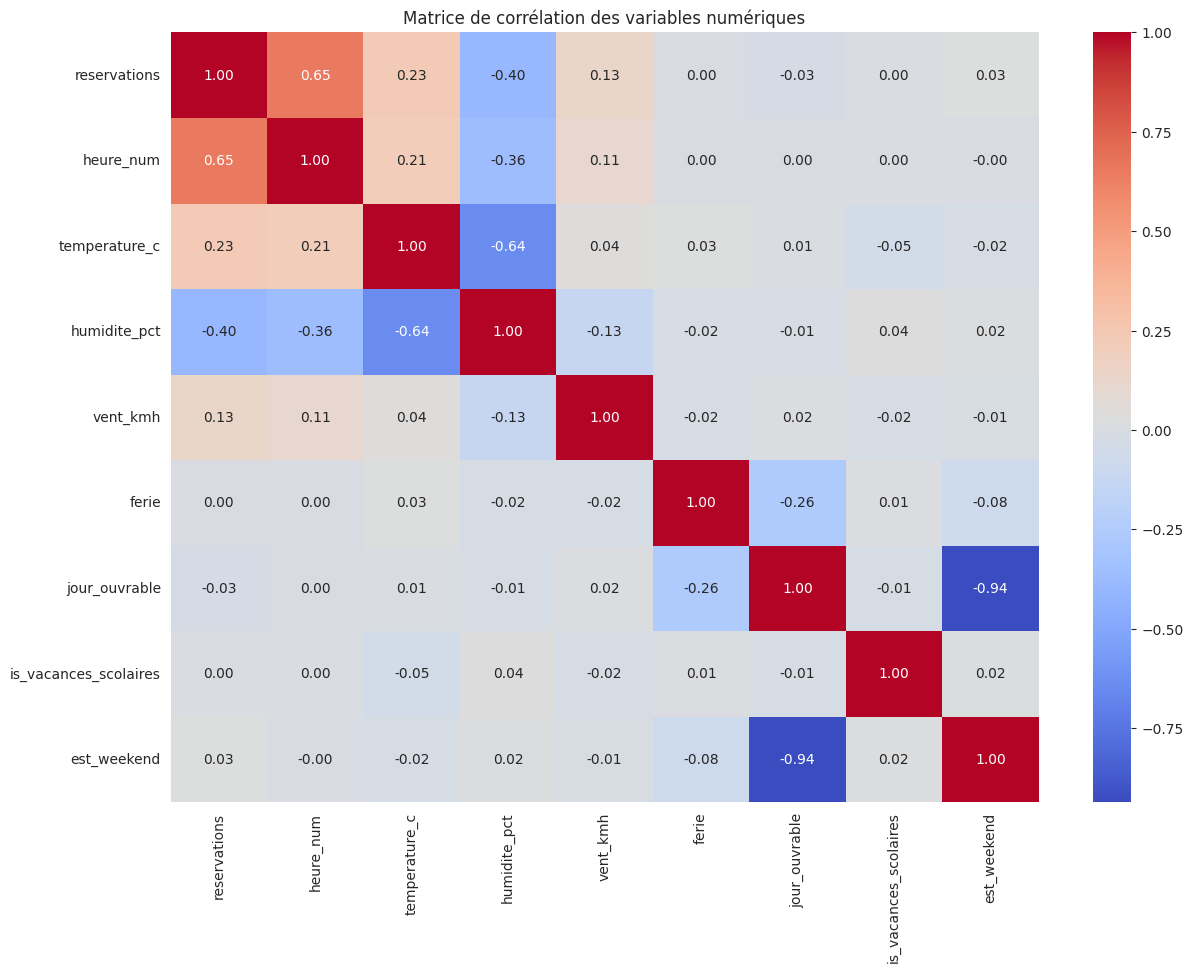

In [13]:
corr_cols = [
    "reservations", "heure_num", "temperature_c", "humidite_pct",
    "vent_kmh", "ferie", "jour_ouvrable",
    "is_vacances_scolaires", "est_weekend"
]

plt.figure(figsize=(14,10))
sns.heatmap(
    df_A_prepared[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

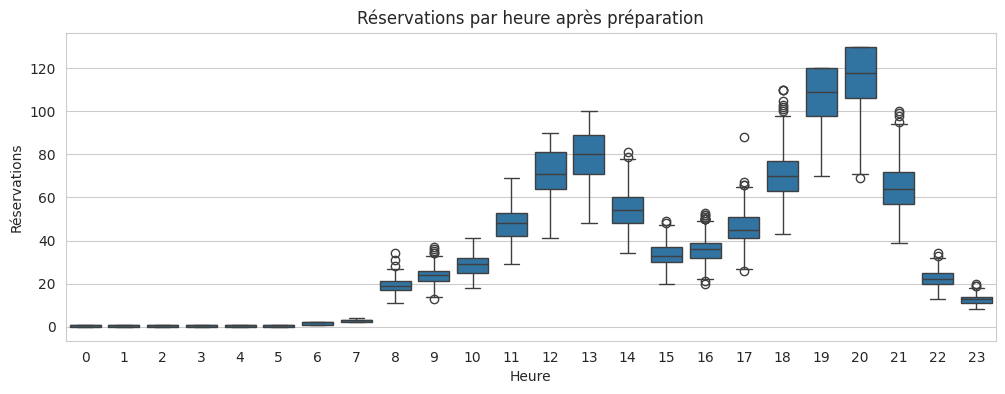

In [14]:
plt.figure(figsize=(12,4))
sns.boxplot(data=df_A_prepared, x="heure_num", y="reservations")
plt.title("Réservations par heure après préparation")
plt.xlabel("Heure")
plt.ylabel("Réservations")
plt.show()

In [15]:
moy_ferie = df_A_prepared.groupby("ferie")["reservations"].mean()
moy_weekend = df_A_prepared.groupby("est_weekend")["reservations"].mean()
moy_vac = df_A_prepared.groupby("is_vacances_scolaires")["reservations"].mean()

print("Variation jours fériés (%) :", round((moy_ferie[1] - moy_ferie[0]) / moy_ferie[0] * 100, 2))
print("Variation week-end (%) :", round((moy_weekend[1] - moy_weekend[0]) / moy_weekend[0] * 100, 2))
print("Variation vacances (%) :", round((moy_vac[1] - moy_vac[0]) / moy_vac[0] * 100, 2))

Variation jours fériés (%) : 0.41
Variation week-end (%) : 5.89
Variation vacances (%) : 0.79
